## TASK 5 — Polynomial Regression (degree 2)

In [1]:
# import libraries
import pandas as pd, yfinance as yf

# select assets and benchmark
TICKER = ["NVDA", "AMD", "INTC"]
BENCH  = ["QQQ"] 
TICKER = TICKER + BENCH

# 3 year period
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(months=36)

# download adjusted close prices
df = yf.download(TICKER, start=start, end=end, interval="1d", auto_adjust=True)[["Close"]]

# flatten column names if multi-index
# i am not sure why the template appends an extra index on the columns
df.columns = [col if isinstance(col, str) else col[1] for col in df.columns]

# reset index to make Date a column
df = df.reset_index()

# sort values by date
df = df.sort_values("Date")

# forward fill and drop any NAs
df = df.ffill().dropna()

# compute returns
df_returns = df[TICKER].pct_change().rename(columns=lambda x: x+ "_Return")

# align return columns to match df
price_cols = df.columns[1:]
df_returns = df_returns[[col + "_Return" for col in price_cols]]

# concatting two datas
df = pd.concat([df, df_returns], axis=1)

# fill returns of the first row to 0
df.fillna(0, inplace=True)

# convert necessary variables to numeric
# consumes a lot of time despite values being numeric already
variables = TICKER + [t + "_Return" for t in TICKER]
for v in variables:
    df[v] = pd.to_numeric(df[v], errors='coerce')

# save files
df.to_csv("prices_clean.csv", index=False)

# ==============================
# TRANSFORMING QUANTITATIVE DATA
# ==============================

# compress wide-format returns into long format
long_df = df.melt(id_vars="Date", value_vars=[t + "_Return" for t in TICKER], var_name="Ticker", value_name="Return")

# clean ticker names
long_df["Ticker"] = long_df["Ticker"].str.replace("_Return", "")

# convert ticker to categorical variables
long_df["Ticker"] = long_df["Ticker"].astype("category")

# save files
long_df.to_csv("returns_long_format.csv", index=False)

[*********************100%***********************]  4 of 4 completed


In [2]:
# template
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# read file
df = pd.read_csv("prices_clean.csv", parse_dates=["Date"]).dropna().sort_values("Date")

# benchmark
bench = BENCH[0] + "_Return"

def quad_regress(asset):
    # prepare quadratic regression
    X = pd.DataFrame({"BenchRet": df[bench], "BenchRet2": df[bench]**2})
    y = df[asset + "_Return"]

    # add constant for intercept
    X = sm.add_constant(X)

    # fit OLS regression
    model = sm.OLS(y, X).fit()
    print(model.summary())
    return model

def scatter_plot(model, asset):    
    # creating a smooth range of bench
    x_vals = np.linspace(df[bench].min(), df[bench].max(), 200)
    y_vals = model.params['const'] + model.params['BenchRet']*x_vals + model.params['BenchRet2']*x_vals**2

    plt.figure(figsize=(8,6))
    plt.scatter(df[bench], df[asset + "_Return"], color='blue', s=20, alpha=0.7, label='Data')
    plt.plot(x_vals, y_vals, color='red', linewidth=2, label='Fitted Quadratic')
    plt.xlabel(f'Benchmark Daily Return ({bench})')
    plt.ylabel(f'{asset} Daily Return')
    plt.title(f'Quadratic Regression of {asset} on {bench}')
    plt.legend()
    plt.grid(True)
    plt.show()

### NVDA

In [3]:
model = quad_regress(TICKER[0])

                            OLS Regression Results                            
Dep. Variable:            NVDA_Return   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     483.1
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          1.75e-135
Time:                        18:00:03   Log-Likelihood:                 1830.4
No. Observations:                 752   AIC:                            -3655.
Df Residuals:                     749   BIC:                            -3641.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0019      0.001      2.347      0.0

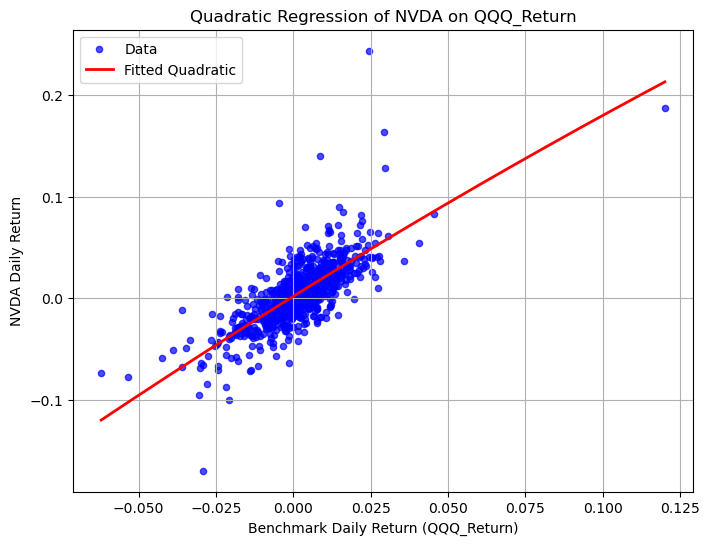

In [4]:
scatter_plot(model, TICKER[0])

### AMD

In [5]:
model = quad_regress(TICKER[1])

                            OLS Regression Results                            
Dep. Variable:             AMD_Return   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     344.9
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          6.64e-107
Time:                        18:00:04   Log-Likelihood:                 1749.8
No. Observations:                 752   AIC:                            -3494.
Df Residuals:                     749   BIC:                            -3480.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.001     -0.127      0.8

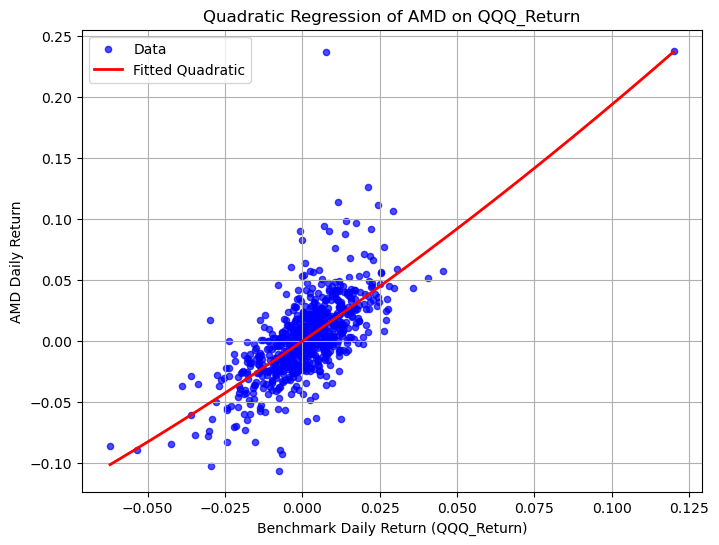

In [6]:
scatter_plot(model, TICKER[1])

### INTC

In [7]:
model = quad_regress(TICKER[2])

                            OLS Regression Results                            
Dep. Variable:            INTC_Return   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     122.3
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.05e-46
Time:                        18:00:04   Log-Likelihood:                 1617.4
No. Observations:                 752   AIC:                            -3229.
Df Residuals:                     749   BIC:                            -3215.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0009      0.001     -0.796      0.4

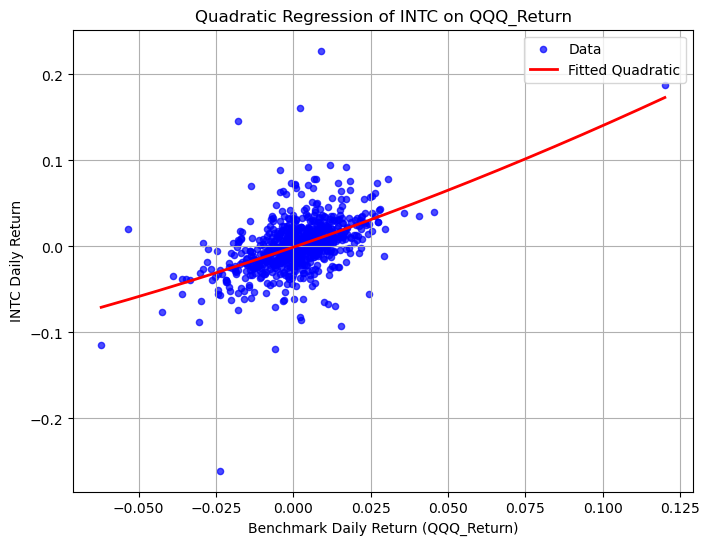

In [8]:
scatter_plot(model, TICKER[2])